In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

data = {
    "Shipment_ID": [f"S{i:03d}" for i in range(1, n + 1)],
    "Region": np.random.choice(
        ["North", "South", "East", "West"], n
    ),
    "Transport_Mode": np.random.choice(
        ["Road", "Rail", "Air"], n,
        p=[0.65, 0.20, 0.15]
    ),
    "Shipment_Volume": np.random.randint(20, 501, n),
    "Distance_km": np.random.randint(50, 1501, n),
    "Delivery_Time_days": np.round(
        np.random.uniform(1, 20, n), 2
    ),
    "Transport_Cost": np.round(
        np.random.uniform(500, 15000, n), 2
    ),
    "Delay_days": np.round(
        np.random.uniform(0, 5, n), 1
    )
}

df = pd.DataFrame(data)

df["On_Time"] = (
    (df["Delay_days"] <= 1) &
    (df["Delivery_Time_days"] <= 20)
).astype(int)

df.head()


,Shipment_ID,Region,Transport_Mode,Shipment_Volume,Distance_km,Delivery_Time_days,Transport_Cost,Delay_days,On_Time
0,S001,East,Road,384,125,3.45,5965.69,2.9,0
1,S002,West,Road,499,314,19.13,7208.86,1.4,0
2,S003,North,Road,391,504,12.52,4869.98,2.8,0
3,S004,East,Road,369,767,5.34,11340.34,3.3,0
4,S005,East,Air,66,784,13.76,7789.45,4.1,0


In [24]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())
df.head()

Shape: (200, 9)

Columns:
Index(['Shipment_ID', 'Region', 'Transport_Mode', 'Shipment_Volume',
       'Distance_km', 'Delivery_Time_days', 'Transport_Cost', 'Delay_days',
       'On_Time'],
      dtype='object')

Data Types:
Shipment_ID            object
Region                 object
Transport_Mode         object
Shipment_Volume         int64
Distance_km             int64
Delivery_Time_days    float64
Transport_Cost        float64
Delay_days            float64
On_Time                 int64
dtype: object

Missing Values:
Shipment_ID           0
Region                0
Transport_Mode        0
Shipment_Volume       0
Distance_km           0
Delivery_Time_days    0
Transport_Cost        0
Delay_days            0
On_Time               0
dtype: int64

Duplicate Rows:
0


,Shipment_ID,Region,Transport_Mode,Shipment_Volume,Distance_km,Delivery_Time_days,Transport_Cost,Delay_days,On_Time
0,S001,East,Road,384,125,3.45,5965.69,2.9,0
1,S002,West,Road,499,314,19.13,7208.86,1.4,0
2,S003,North,Road,391,504,12.52,4869.98,2.8,0
3,S004,East,Road,369,767,5.34,11340.34,3.3,0
4,S005,East,Air,66,784,13.76,7789.45,4.1,0


In [25]:
df.describe()

,Shipment_Volume,Distance_km,Delivery_Time_days,Transport_Cost,Delay_days,On_Time
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,261.600000,867.535000,9.698150,7492.179250,2.56250,0.190000
std,134.778881,405.760839,5.286216,4173.039249,1.48488,0.393285
min,20.000000,59.000000,1.280000,567.160000,0.10000,0.000000
25%,140.500000,547.000000,4.785000,3807.305000,1.20000,0.000000
50%,265.500000,921.500000,9.325000,7203.970000,2.60000,0.000000
75%,381.000000,1218.000000,13.760000,11024.262500,3.90000,0.000000
max,499.000000,1495.000000,19.810000,14954.680000,5.00000,1.000000


In [26]:
df[[
    "Shipment_Volume",
    "Distance_km",
    "Delivery_Time_days",
    "Transport_Cost",
    "Delay_days"
]].describe()

,Shipment_Volume,Distance_km,Delivery_Time_days,Transport_Cost,Delay_days
count,200.000000,200.000000,200.000000,200.000000,200.00000
mean,261.600000,867.535000,9.698150,7492.179250,2.56250
std,134.778881,405.760839,5.286216,4173.039249,1.48488
min,20.000000,59.000000,1.280000,567.160000,0.10000
25%,140.500000,547.000000,4.785000,3807.305000,1.20000
50%,265.500000,921.500000,9.325000,7203.970000,2.60000
75%,381.000000,1218.000000,13.760000,11024.262500,3.90000
max,499.000000,1495.000000,19.810000,14954.680000,5.00000


In [27]:
average_delivery = df["Delivery_Time_days"].mean()
average_cost = df["Transport_Cost"].mean()
average_delay = df["Delay_days"].mean()
on_time_rate = df["On_Time"].mean() * 100

print("Average Delivery Time:", round(average_delivery, 2))
print("Average Transportation Cost:", round(average_cost, 2))
print("Average Delay:", round(average_delay, 2))
print("On-Time Delivery Rate:", round(on_time_rate, 2), "%")

Average Delivery Time: 9.7
Average Transportation Cost: 7492.18
Average Delay: 2.56
On-Time Delivery Rate: 19.0 %


In [28]:
mode_analysis = df.groupby("Transport_Mode").agg({
    "Delivery_Time_days": "mean",
    "Transport_Cost": "mean",
    "Delay_days": "mean",
    "On_Time": "mean"
})

mode_analysis["On_Time"] = mode_analysis["On_Time"] * 100

mode_analysis

,Delivery_Time_days,Transport_Cost,Delay_days,On_Time
Transport_Mode,,,,
Air,10.311714,7027.822000,2.431429,25.714286
Rail,10.590833,8352.704444,2.694444,19.444444
Road,9.282558,7378.021085,2.561240,17.054264


In [29]:
region_analysis = df.groupby("Region").agg({
    "Delivery_Time_days": "mean",
    "Transport_Cost": "mean",
    "Delay_days": "mean",
    "On_Time": "mean"
})

region_analysis["On_Time"] = region_analysis["On_Time"] * 100

region_analysis

,Delivery_Time_days,Transport_Cost,Delay_days,On_Time
Region,,,,
East,9.929074,8436.649630,2.629630,18.518519
North,10.245435,7680.782391,2.378261,26.086957
South,8.867826,6971.751739,2.791304,8.695652
West,9.708333,6830.374074,2.457407,22.222222


In [30]:
correlation = df[[
    "Shipment_Volume",
    "Distance_km",
    "Delivery_Time_days",
    "Transport_Cost",
    "Delay_days"
]].corr()

correlation

,Shipment_Volume,Distance_km,Delivery_Time_days,Transport_Cost,Delay_days
Shipment_Volume,1.000000,0.010326,-0.176929,-0.091163,-0.068332
Distance_km,0.010326,1.000000,0.002450,-0.065553,0.004818
Delivery_Time_days,-0.176929,0.002450,1.000000,-0.016519,0.074940
Transport_Cost,-0.091163,-0.065553,-0.016519,1.000000,-0.017715
Delay_days,-0.068332,0.004818,0.074940,-0.017715,1.000000


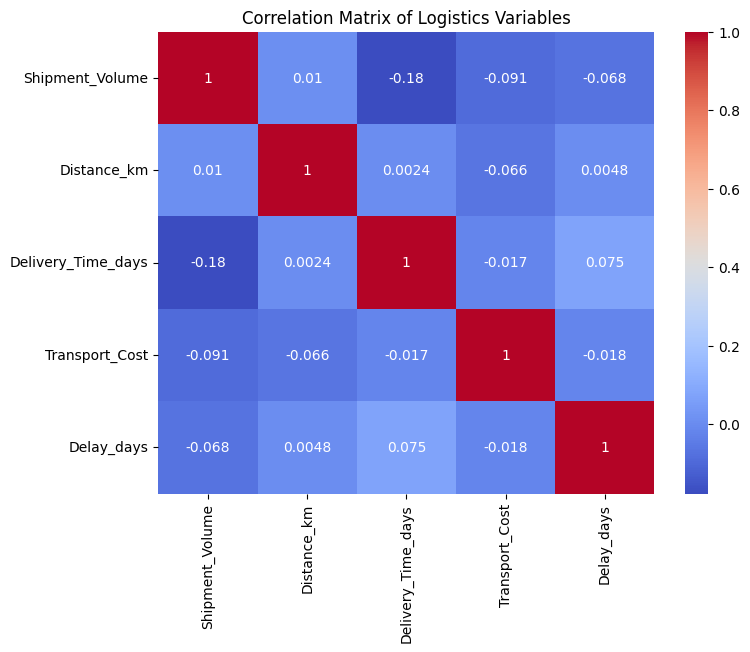

In [31]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Logistics Variables")
plt.show()

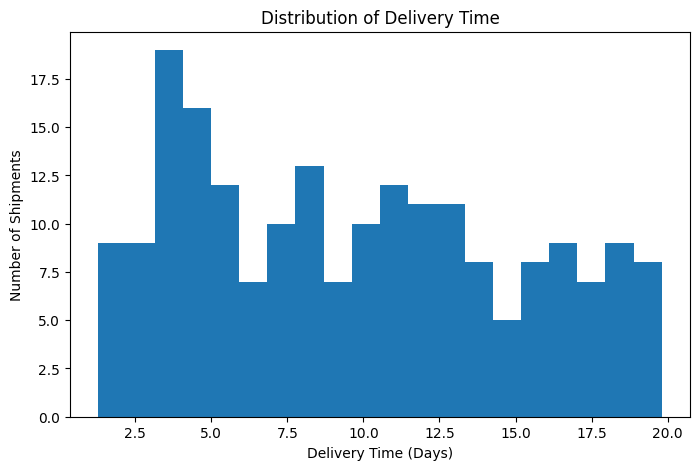

In [32]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Delivery_Time_days"],
    bins=20
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Shipments")

plt.show()

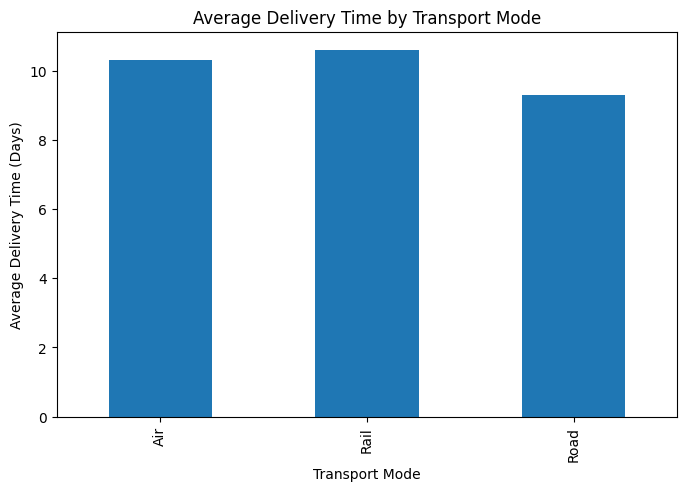

In [33]:
plt.figure(figsize=(8,5))

df.groupby("Transport_Mode")[
    "Delivery_Time_days"
].mean().plot(kind="bar")

plt.title("Average Delivery Time by Transport Mode")
plt.xlabel("Transport Mode")
plt.ylabel("Average Delivery Time (Days)")

plt.show()

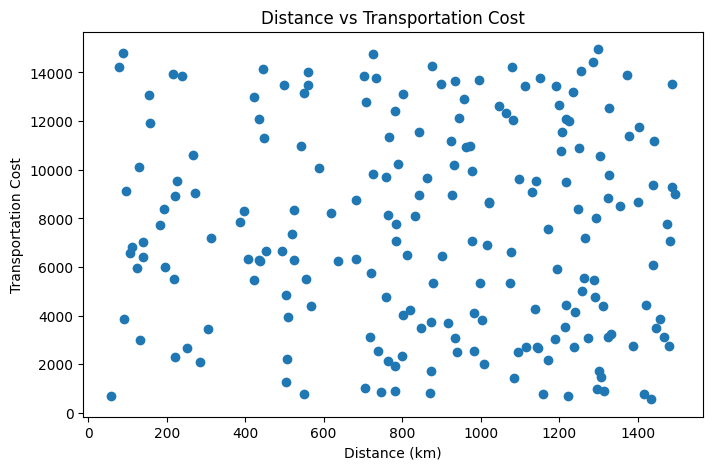

In [34]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Distance_km"],
    df["Transport_Cost"]
)

plt.title("Distance vs Transportation Cost")
plt.xlabel("Distance (km)")
plt.ylabel("Transportation Cost")

plt.show()

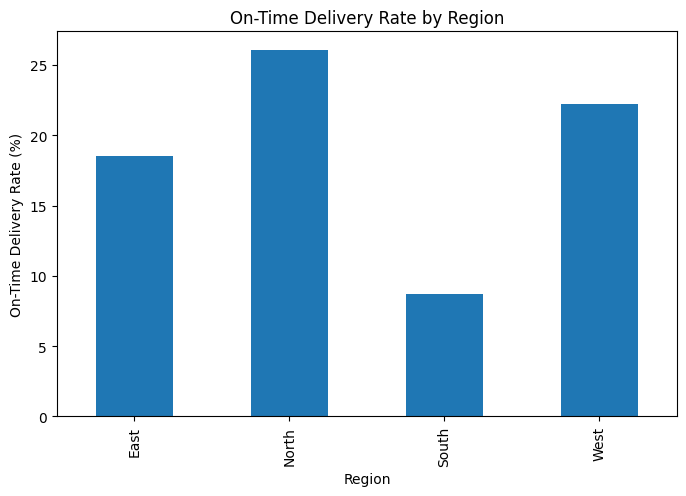

In [35]:
plt.figure(figsize=(8,5))

df.groupby("Region")["On_Time"].mean().mul(100).plot(
    kind="bar"
)

plt.title("On-Time Delivery Rate by Region")
plt.xlabel("Region")
plt.ylabel("On-Time Delivery Rate (%)")

plt.show()

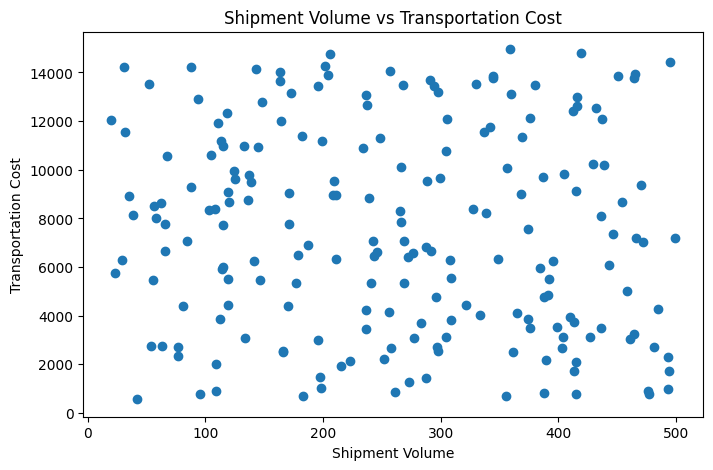

In [36]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Shipment_Volume"],
    df["Transport_Cost"]
)

plt.title("Shipment Volume vs Transportation Cost")
plt.xlabel("Shipment Volume")
plt.ylabel("Transportation Cost")

plt.show()

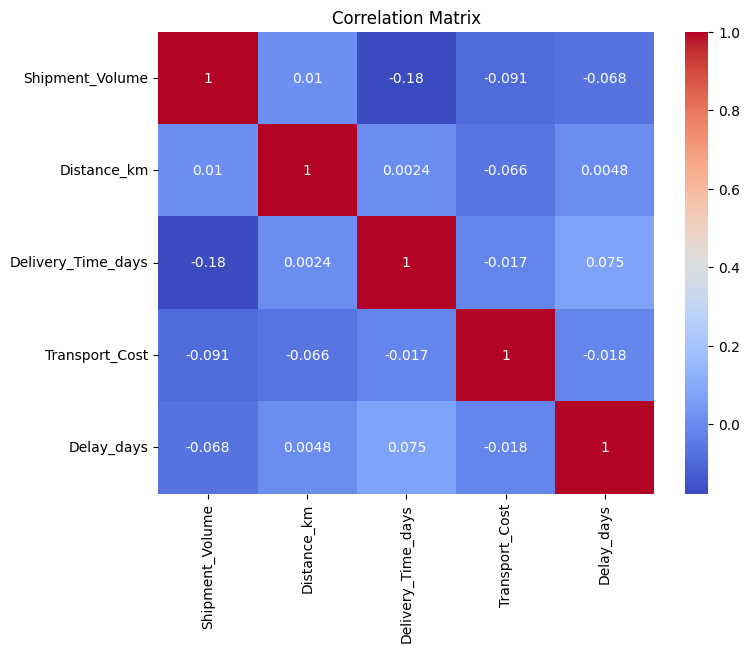

In [37]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [38]:
df.to_csv(
    "hypothetical_logistics_dataset.csv",
    index=False
)